# 03. Feature Analysis
Given a specific modeling approach, attempt to determine which features are attended for classification results. Additionally, attempt to obtain Shapley values for the features and present on a figure.

In [2]:
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

data_df = None
if os.path.isfile("data/data.pkl"):
    data_df = pd.read_pickle("data/data.pkl")
else:
    print("Load Data")
data_df.head()

/home/km/Documents/Local/Files/Academic/Research/BrainConnectivity/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Subject_ID,Diagnosis,Study,Data,Connectome,EVC,CLU,DIV
0,1144,HC,MUSC,"[[58.73076183, 136.138853, 71.32999539, 41.065...","[[0.0, -0.14159653131781452, -0.01696992835995...","[0.00882765564582845, 0.012992044516828722, 0....","[0.006690112258848986, 0.00677957588786147, 0....","[0.9874632735385, 0.9796586961296364, 0.964520..."
1,1104,HC,MUSC,"[[12.18384103, -31.72224568, 11.98897454, 2.31...","[[0.0, -0.05963586996156045, -0.00447346309142...","[0.0030474747387929666, 0.027722135075707012, ...","[0.009840366701664785, 0.011338349699506192, 0...","[0.9619945142677632, 0.9612533230954341, 0.975..."
2,1085,HC,MUSC,"[[-1.300582984, -6.808979653, -28.1579185, 7.3...","[[0.0, -0.2652810998939504, 0.0209836959172419...","[0.036331611587248874, 0.025120921603343362, 0...","[0.014165572069570698, 0.013515561660305219, 0...","[0.9800037416273699, 0.9761500612391321, 0.969..."
3,1051,HC,MUSC,"[[23.00822698, -126.074722, 77.52625116, 17.74...","[[0.0, -0.05925102455996451, -0.03625953478906...","[0.00791636744924377, 0.03611860964572453, 0.0...","[0.012860192895338064, 0.012706715663247686, 0...","[0.9669454007797847, 0.97436119789489, 0.96890..."
4,1155,HC,MUSC,"[[-6.295390793, -24.09210886, 31.53133265, -28...","[[0.0, -0.037840818730998683, -0.0440939570337...","[0.017409557893134447, 0.010886255401032623, 0...","[0.010173478405801618, 0.010274142338296474, 0...","[0.9544663828468297, 0.9249482579239692, 0.952..."


In [3]:
tbi_df = data_df[data_df["Study"] == "TBI"]
tbi_evc = np.vstack(tbi_df["EVC"])
tbi_class = np.where(tbi_df["Diagnosis"] == "POS", 1, 0)

In [17]:
state = 100

clf = svm.SVC(
    kernel="sigmoid",
    class_weight="balanced",
    probability=True,
    random_state=state
)

scaler = StandardScaler()
tbi_evc_scaled = scaler.fit_transform(tbi_evc)

x_train, x_test, y_train, y_test = train_test_split(tbi_evc_scaled, 
                                                    tbi_class, 
                                                    random_state=state, 
                                                    stratify=tbi_class)
feature_variance = pd.DataFrame(x_train).var(axis=0)
print("Feature Variance:\n", feature_variance)

svc_params = {
        'C': np.linspace(0.1, 10, 25),
        'kernel': ['linear', 'rbf', 'sigmoid'],
        'gamma': np.logspace(1e-10, 1, 10),
    }

gridsearch = GridSearchCV(estimator=clf,
                          param_grid=svc_params,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=state),
                          refit=True)
gridsearch.fit(x_train, y_train)
best_model = gridsearch.best_estimator_

explainer = shap.KernelExplainer(best_model.predict_proba, x_train)
shap_values = explainer.shap_values(x_test)
shap_pos_class = shap_values[:,:,1]
shap_values_pos = shap.Explanation(
    values=shap_pos_class,
    base_values=explainer.expected_value[1],
    data=x_test,
    feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])]
)

Feature Variance:
 0      0.616566
1      0.271462
2      0.521185
3      1.066383
4      1.070150
         ...   
248    1.281649
249    0.744428
250    0.214740
251    1.117739
252    0.998874
Length: 253, dtype: float64


100%|██████████| 15/15 [00:28<00:00,  1.92s/it]


In [5]:
gridsearch.cv # Look at the cross-validation grid search feature values. So few test cases. Run a LASSO to see important ft

StratifiedKFold(n_splits=5, random_state=100, shuffle=True)

Best Model Parameters: {'C': np.float64(0.1), 'gamma': np.float64(1.0000000002302585), 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.60      0.75      0.67         8
           1       0.60      0.43      0.50         7

    accuracy                           0.60        15
   macro avg       0.60      0.59      0.58        15
weighted avg       0.60      0.60      0.59        15

Confusion Matrix:
 [[6 2]
 [4 3]]
Feature Importances:
 [ 0.04        0.05333333 -0.04        0.          0.06666667  0.
  0.04        0.08        0.          0.          0.05333333  0.02666667
  0.          0.02666667  0.          0.          0.10666667  0.05333333
  0.01333333 -0.02666667  0.04       -0.05333333  0.          0.04
  0.05333333  0.04        0.          0.          0.12        0.05333333
  0.          0.01333333  0.05333333  0.01333333 -0.01333333  0.
  0.          0.          0.05333333  0.          0.06666667  0.09333333
  0.04        0.02666667

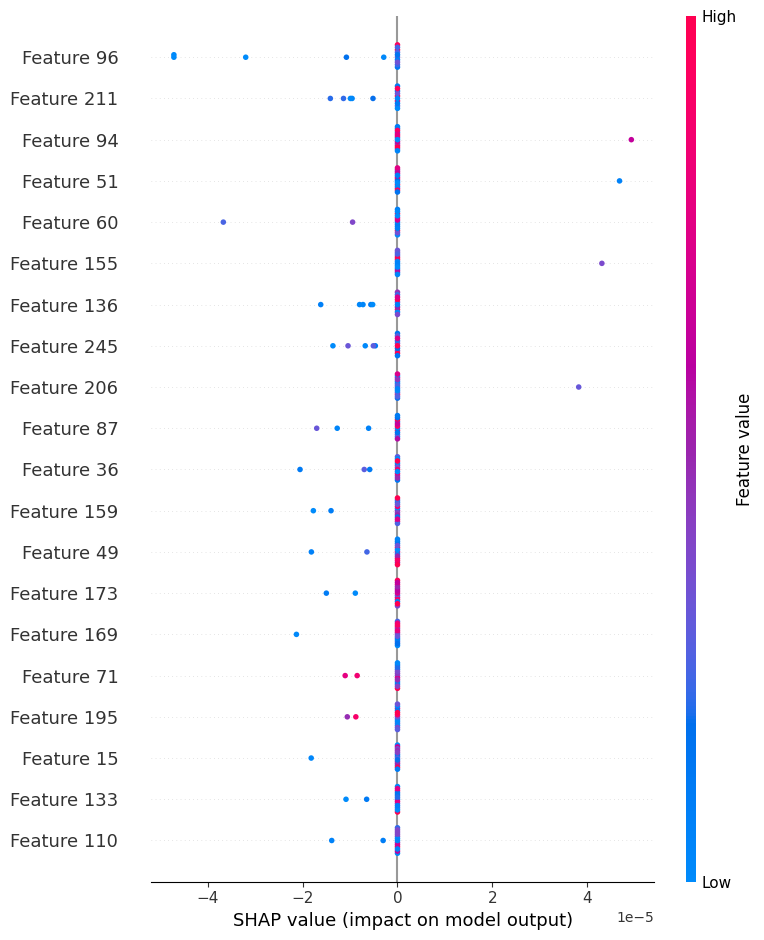

In [18]:
print("Best Model Parameters:", gridsearch.best_params_)

y_predict = best_model.predict(x_test)
print(classification_report(y_test, y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))

importances = permutation_importance(best_model, x_test, y_test, scoring="accuracy")
print("Feature Importances:\n", importances.importances_mean)

shap.summary_plot(shap_pos_class, x_test, feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])])

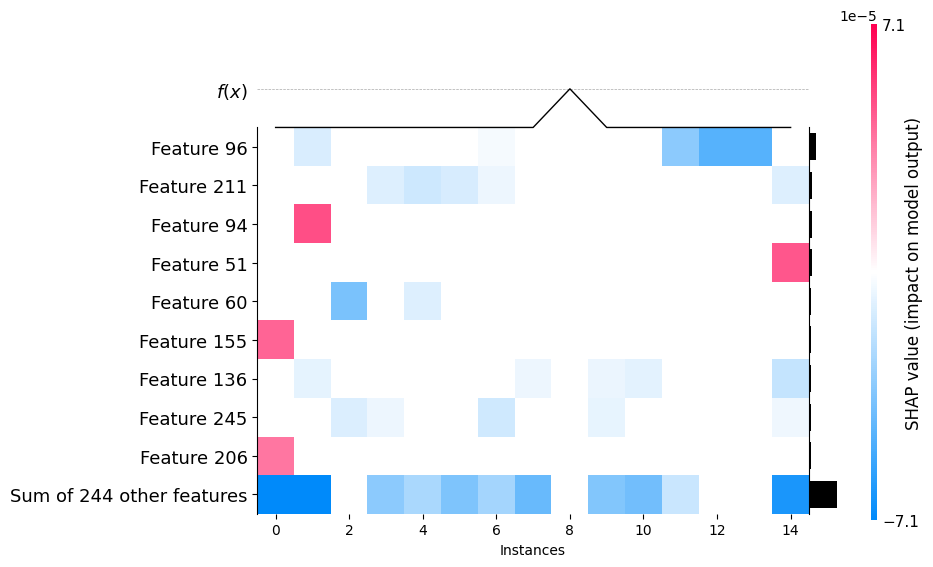

<Axes: xlabel='Instances'>

In [19]:
shap.plots.heatmap(shap_values_pos)

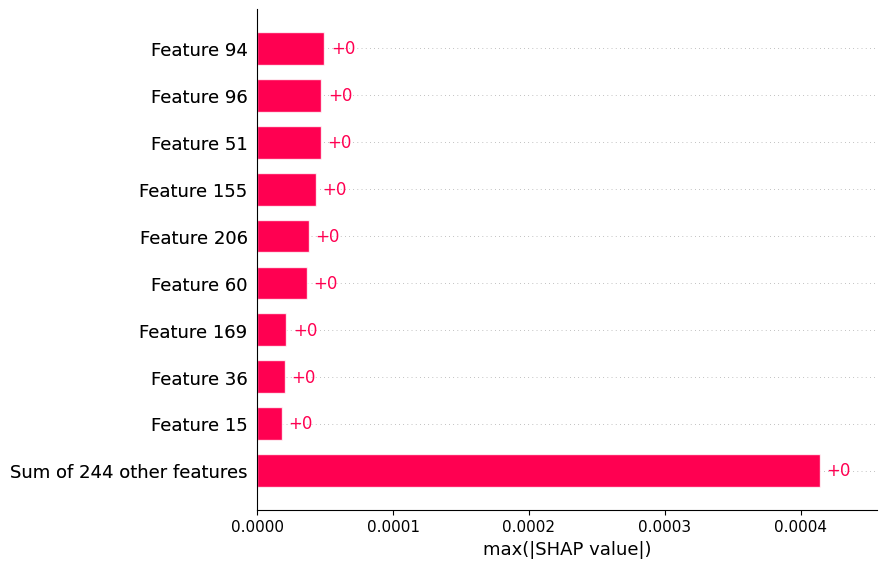

In [20]:
shap.plots.bar(shap_values_pos.abs.max(0))

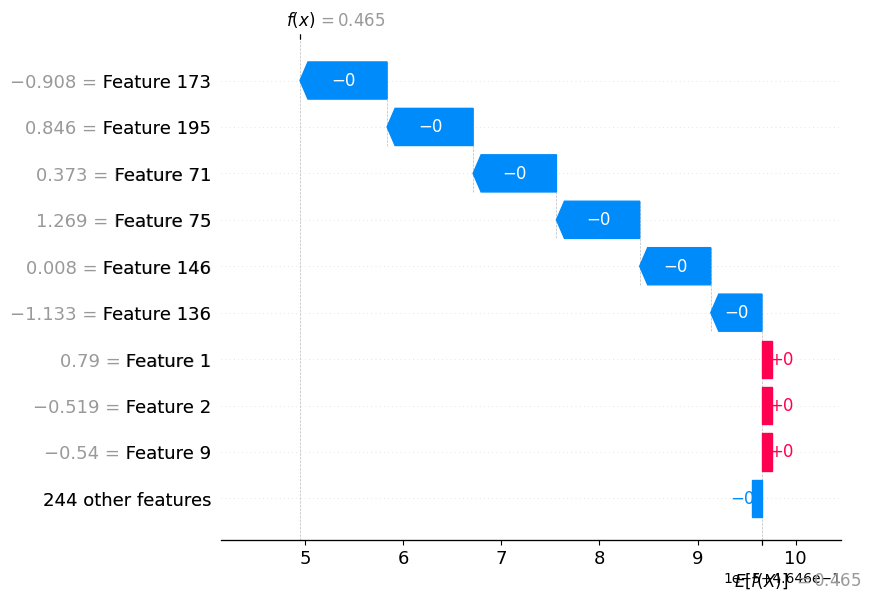

In [21]:
# Waterfall plots display individual predictions, so they expect a single row 
# of an Explanation object as input
sample_ind = 0 
shap.waterfall_plot(shap.Explanation(values=shap_pos_class[sample_ind],
                                     base_values=explainer.expected_value[1],
                                     data=x_test[sample_ind],
                                     feature_names=[f"Feature {i+1}" for i in range(x_test.shape[1])]))


### LASSO

In [25]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

reg = Lasso(alpha=1)
reg.fit(x_train, y_train)
print('R squared training set', round(reg.score(x_train, y_train)*100, 2))
print('R squared test set', round(reg.score(x_test, y_test)*100, 2))

# Training data
pred_train = reg.predict(x_train)
mse_train = mean_squared_error(y_train, pred_train)
print('MSE training set', round(mse_train, 2))

# Test data
pred = reg.predict(x_test)
mse_test = mean_squared_error(y_test, pred)
print('MSE test set', round(mse_test, 2))

R squared training set 0.0
R squared test set -0.45
MSE training set 0.25
MSE test set 0.25


Computing regularization path using the lasso...
Best alpha: 0.07737592403802704
Coefficients at best alpha:
Feature index 1: Coefficient 0.05425224660111335
Feature index 5: Coefficient -0.04689989440958884
Feature index 15: Coefficient -0.0045446697336337695
Feature index 24: Coefficient -0.00520725518586028
Feature index 51: Coefficient 0.09716438516959533
Feature index 53: Coefficient 0.04561047626987156
Feature index 76: Coefficient 0.044915878325585516
Feature index 78: Coefficient 0.001915916241577024
Feature index 92: Coefficient 0.003478695200188071
Feature index 111: Coefficient -0.05248753614064072
Feature index 125: Coefficient 0.010913034918495816
Feature index 130: Coefficient -0.07769385464547923
Feature index 137: Coefficient 0.03915782259955702
Feature index 142: Coefficient -0.0013850440392250704
Feature index 169: Coefficient -0.02610193659611082
Feature index 173: Coefficient -0.008215814616346528
Feature index 183: Coefficient -0.051275267032008534
Feature index 19

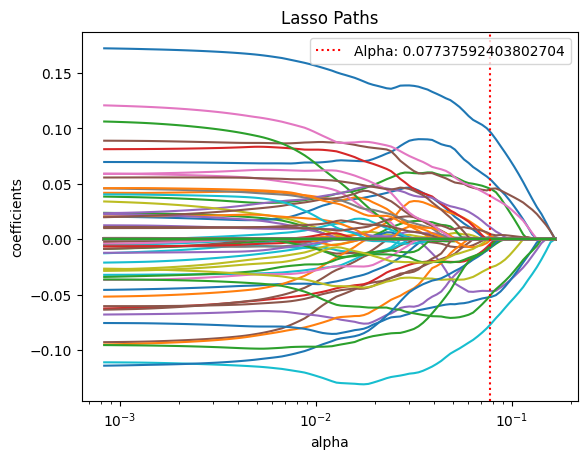

In [24]:
from sklearn.linear_model import lasso_path, LassoCV, Lasso
from itertools import cycle
print("Computing regularization path using the lasso...")
eps = 5e-3
alphas_lasso, coefs_lasso, _ = lasso_path(tbi_evc_scaled, tbi_class, eps=eps)

plt.figure(1)
for coef_lasso in coefs_lasso:
    l1 = plt.semilogx(alphas_lasso, coef_lasso)

plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso Paths")
plt.axis("tight")

lasso_cv = LassoCV(cv=5, random_state=state, max_iter=10000)
lasso_cv.fit(tbi_evc_scaled, tbi_class)
best_alpha = lasso_cv.alpha_
print(f"Best alpha: {best_alpha}")

plt.axvline(x=best_alpha, color='red', linestyle='dotted', label=f"Alpha: {best_alpha}")

lasso_best = Lasso(alpha=best_alpha)
lasso_best.fit(tbi_evc_scaled, tbi_class)
coefficients = lasso_best.coef_
nonzero_indices = np.where(coefficients != 0)[0]

print("Coefficients at best alpha:")
for idx, coef in zip(nonzero_indices, coefficients[nonzero_indices]):
        print(f"Feature index {idx+1}: Coefficient {coef}")
# print(list(lasso_best.coef_,))

plt.legend()
plt.show()
